,Year,Event,Driver,Compound,CompoundEncoded,TyreLife,TrackTemp,FuelLoad,Abrasivity,LateralEnergy,DeltaToBest,LapNumber,Stint,CorrectedLapTime_Global,BestCorrectedByStint
0,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,4.0,31.8,54.0,3.1,3.1,0.000000,4.0,1.0,89.572000,89.572
1,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,5.0,31.7,53.0,3.1,3.1,0.490478,5.0,1.0,90.062478,89.572
2,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,6.0,31.8,52.0,3.1,3.1,0.107828,6.0,1.0,89.679828,89.572
3,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,7.0,31.8,51.0,3.1,3.1,0.432000,7.0,1.0,90.004000,89.572
4,2024,Abu Dhabi Grand Prix,1,MEDIUM,1,8.0,31.9,50.0,3.1,3.1,0.549765,8.0,1.0,90.121765,89.572


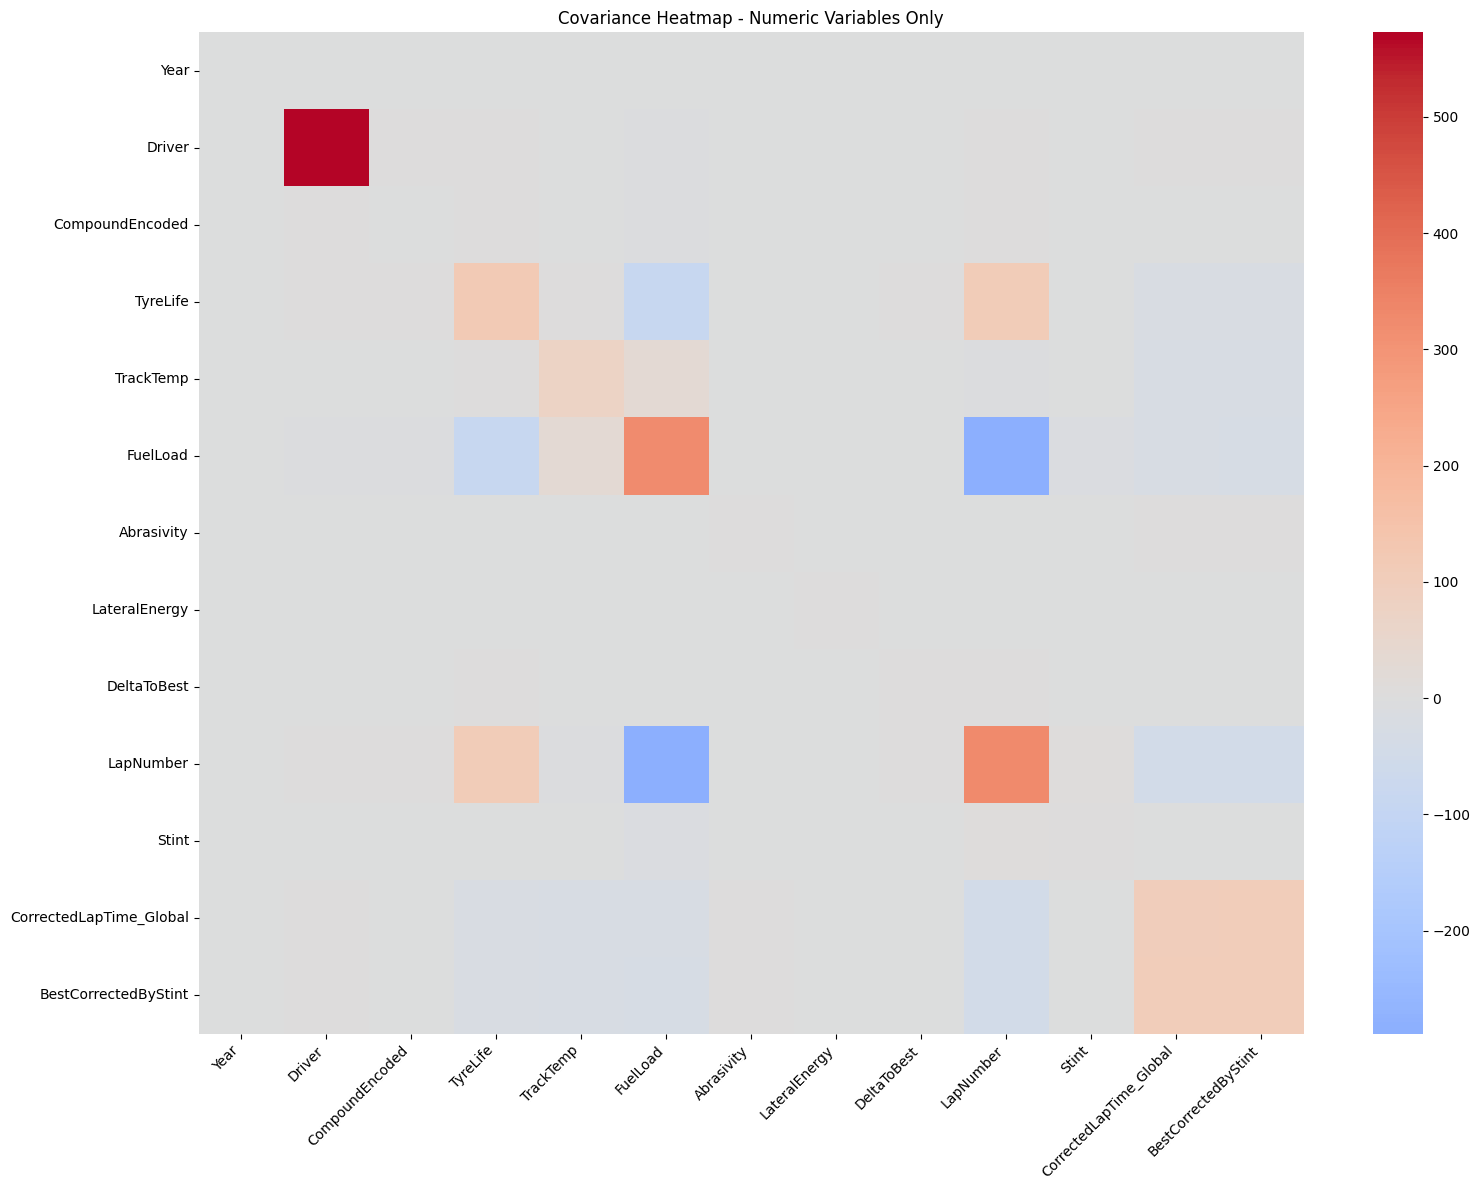

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../classes/master_dataset_partie2_2024.csv")
display(df.head())

# Keep numeric columns only.
df_num = df.select_dtypes(include=[np.number]).copy()

# Remove constant columns (variance = 0) because they add no information.
constant_cols = [c for c in df_num.columns if df_num[c].nunique(dropna=True) <= 1]
df_num = df_num.drop(columns=constant_cols, errors="ignore")

# Exclude identifier-like columns that can dominate covariance scale.
id_like_cols = [c for c in ["Driver", "Year"] if c in df_num.columns]
df_analysis = df_num.drop(columns=id_like_cols, errors="ignore")

print("Removed constant columns:", constant_cols)
print("Excluded id-like columns:", id_like_cols)
print("Columns used for analysis:", df_analysis.columns.tolist())

# 1) Covariance heatmap (continuous scale can still be large).
cov_num = df_analysis.cov()
plt.figure(figsize=(14, 10))
sns.heatmap(cov_num, annot=False, cmap="coolwarm", center=0)
plt.title("Covariance Heatmap - Filtered Numeric Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2) Correlation heatmap (recommended for readability/comparison).
corr_num = df_analysis.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap - Filtered Numeric Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3) Optional: include categorical variables by encoding them to integer codes.
include_categorical = False

if include_categorical:
    df_cat = df.select_dtypes(include=["object", "category", "bool"]).copy()
    for col in df_cat.columns:
        df_cat[col] = pd.Categorical(df_cat[col]).codes

    df_mixed = pd.concat([df_analysis, df_cat], axis=1)
    corr_mixed = df_mixed.corr()

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_mixed, annot=False, cmap="coolwarm", vmin=-1, vmax=1, center=0)
    plt.title("Correlation Heatmap - Numeric + Encoded Categorical")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()